# 0. 项目初始化
将`conditional-flow-matching`文件夹上传到kaggle中, 然后进行以下操作.本项目文件夹已经包含数据集`data/`,项目运行后,输出在模型文件夹`notes/models/`下.

注意: 设置settings-environment preferences-pin to original environment可以解决python版本与依赖不兼容报错的问题

此文件的目的:

- 用eb umap数据， 绘制ot cfm和partial ot cfm 的轨迹

- 优化`plot_plot_trajectories`绘图逻辑，不再绘制多余且丑陋的红色轨迹

- 优化partial ot数值爆炸问题, 修改源代码, 需要重新上传input

In [2]:
# cd /kaggle/input/datasets/nevermeant4/cfm-eb/conditional-flow-matching

import os
os.chdir("../..")
os.getcwd()

'd:\\desktop\\code\\conditional-flow-matching'

In [2]:
# !pip install -r requirements.txt

# 1. 类胚体数据

## 单细胞时间序列插值

本笔记本在类胚体（embryoid body）数据上运行OT-CFM、POT-CFM两种模型，数据预处理过程参考`preprocessing`（预处理）文件夹中的笔记本。本文中，我们优化了一个单一网络，用于在二维PHATE投影上对不同时间点的细胞进行建模。该流程同样适用于其他任何数据表征方式。在研究论文中，我们基于主成分分析（PCA）组件和高可变基因（highly variable genes）对模型进行了定量比较。

在本文的模型训练中，我们将所有时间点对整合为一个批次（batch）。在硬件支持大批次数据处理的情况下，这种方式被证明是最稳定的训练策略。

In [ ]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

import warnings

# 忽略所有警告
warnings.filterwarnings("ignore")

# 模型路径
# savedir = "/kaggle/working/models/ebdata"
savedir = "./notes/experiment/models/ebdata"
os.makedirs(savedir, exist_ok=True)

d:\develop\anaconda\envs\cfm-runner\lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
# adata = sc.read_h5ad("./data/Processed Single-cell RNA Time Series DAta/ebdata_v3.h5ad")
adata = sc.read_h5ad("./runner/data/Processed Single-cell RNA Time Series DAta/ebdata_v3.h5ad")
adata

AnnData object with n_obs × n_vars = 18203 × 17789
    obs: 'sample_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'leiden', 'dpt_pseudotime', '1d-phate', '1d-phate-normalized'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_name', 'gene_id', 'gene_name_id'
    uns: 'diffmap_evals', 'iroot', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'sample_labels_colors', 'tsne', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_phate', 'X_phate_normalized', 'X_phate_real_time', 'X_phate_time', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

In [5]:
adata.obsm['X_pca'].shape

(18203, 50)

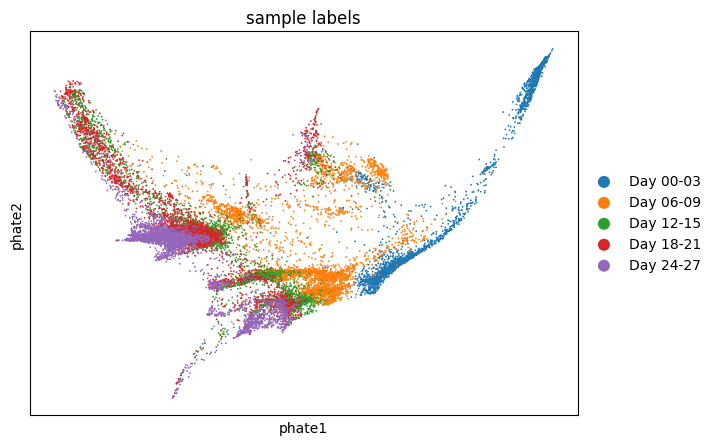

In [6]:
# phate降维后的图像
sc.pl.scatter(adata, basis="phate", color="sample_labels")

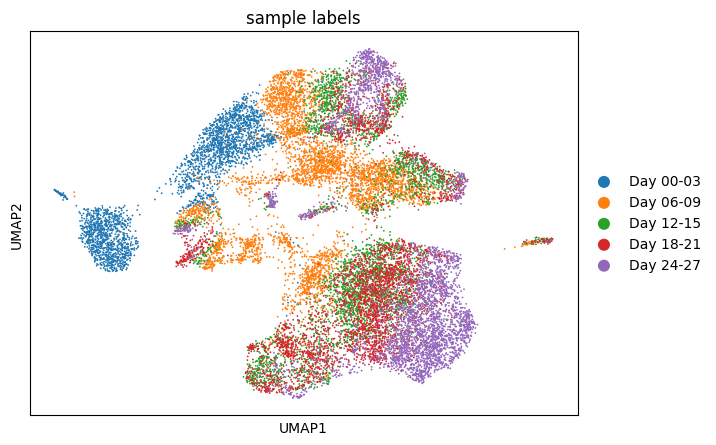

In [7]:
# umap降维
sc.pl.scatter(adata, basis="umap", color="sample_labels")

In [8]:
# (可选)子采样， 暂时只用完整数据
import scanpy as sc
import numpy as np

# 随机抽取 10000 个细胞（不重复，保留所有标签、UMAP、PCA）
# 固定随机种子，结果可复现
np.random.seed(42)
eb_subset = adata[np.random.choice(adata.n_obs, size=10000, replace=False)]

# 查看结果（会变成 10000 × 17789）
print(eb_subset)

View of AnnData object with n_obs × n_vars = 10000 × 17789
    obs: 'sample_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'leiden', 'dpt_pseudotime', '1d-phate', '1d-phate-normalized'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_name', 'gene_id', 'gene_name_id'
    uns: 'diffmap_evals', 'iroot', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'sample_labels_colors', 'tsne', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_phate', 'X_phate_normalized', 'X_phate_real_time', 'X_phate_time', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'


In [9]:
# n_times = 5,五个标签
n_times = len(adata.obs["sample_labels"].unique())
# Standardize coordinates
# 标准化坐标,分布为均值0方差1
coords = adata.obsm["X_umap"]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm["X_umap_standardized"] = coords
# X: 将坐标coords分为五个标签,每个标签含若干n_i个细胞,形状为 (5,n_i,2)
X = [
    adata.obsm["X_umap_standardized"][adata.obs["sample_labels"].cat.codes == t]
    for t in range(n_times)
]

In [10]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 256
sigma = 0.1
dim = 2
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)

In [11]:
import scprep

# 这个函数重载了原来的轨迹绘图 多画了15条不美观的红线轨迹
def plot_trajectories(traj, legend=True):
    n = 2000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    scprep.plot.scatter(
        adata.obsm["X_umap_standardized"][:, 0],
        adata.obsm["X_umap_standardized"][:, 1],
        c=adata.obs["sample_labels"],
        ax=ax,
    )
    # ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    # ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    # for i in range(15):
    #     ax.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    if legend:
        plt.legend([r"$p_0$", r"$p_t$", r"$p_1$", r"$X_t \mid X_0$"])
    # plt.xticks([])
    # plt.yticks([])
    # plt.axis("off")

def plot_trajectories(traj, legend=True):
    n = 2000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    
    # 背景 UMAP
    scprep.plot.scatter(
        adata.obsm["X_umap_standardized"][:, 0],
        adata.obsm["X_umap_standardized"][:, 1],
        c=adata.obs["sample_labels"],
        ax=ax,
        s=3,
        alpha=0.6
    )

    # 轨迹：透明灰色
    traj_line = ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.5, alpha=0.15, c="#999999")
    
    # 起点：浅蓝
    start_point = ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=7, alpha=0.9, c="#99ccff")
    
    # 终点：浅紫
    end_point = ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=7, alpha=0.9, c="#e0b3ff")

    # 图例对应
    if legend:
        ax.legend(
            [start_point, traj_line, end_point],
            ["Start", "Trajectory", "End"],
            loc="best"
        )

    plt.tight_layout()
    plt.show()


def get_batch(FM, X, batch_size, n_times, return_noise=False):
    """Construct a batch with points from each timepoint pair"""
    ts = []
    xts = []
    uts = []
    noises = []
    for t_start in range(n_times - 1):
        x0 = (
            torch.from_numpy(X[t_start][np.random.randint(X[t_start].shape[0], size=batch_size)])
            .float()
            .to(device)
        )
        x1 = (
            torch.from_numpy(
                X[t_start + 1][np.random.randint(X[t_start + 1].shape[0], size=batch_size)]
            )
            .float()
            .to(device)
        )
        if return_noise:
            t, xt, ut, eps = FM.sample_location_and_conditional_flow(
                x0, x1, return_noise=return_noise
            )
            noises.append(eps)
        else:
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1, return_noise=return_noise)
        ts.append(t + t_start)
        xts.append(xt)
        uts.append(ut)
    t = torch.cat(ts)
    xt = torch.cat(xts)
    ut = torch.cat(uts)
    if return_noise:
        noises = torch.cat(noises)
        return t, xt, ut, noises
    return t, xt, ut

# 1.1 OT-CFM
最优传输流匹配

In [12]:
loss_history = []  # 保存每1000步的loss
for i in tqdm(range(10000)):
    ot_cfm_optimizer.zero_grad()
    t, xt, ut = get_batch(FM, X, batch_size, n_times)
    vt = ot_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)
    loss.backward()
    ot_cfm_optimizer.step()
    # 每1000步记录loss
    if (i + 1) % 1000 == 0:
        loss_val = loss.item()
        loss_history.append(loss_val)
        tqdm.write(f"迭代步数: {i+1:5d} | Loss: {loss_val:.6f}")

 10%|█         | 1004/10000 [00:39<07:13, 20.77it/s]

迭代步数:  1000 | Loss: 0.111496


 20%|██        | 2004/10000 [01:10<03:54, 34.08it/s]

迭代步数:  2000 | Loss: 0.101358


 30%|███       | 3004/10000 [01:41<04:01, 28.99it/s]

...

迭代步数:  8000 | Loss: 0.084814


 90%|█████████ | 9003/10000 [05:47<00:41, 24.07it/s]

迭代步数:  9000 | Loss: 0.070700


100%|██████████| 10000/10000 [06:23<00:00, 26.06it/s]

迭代步数: 10000 | Loss: 0.073699


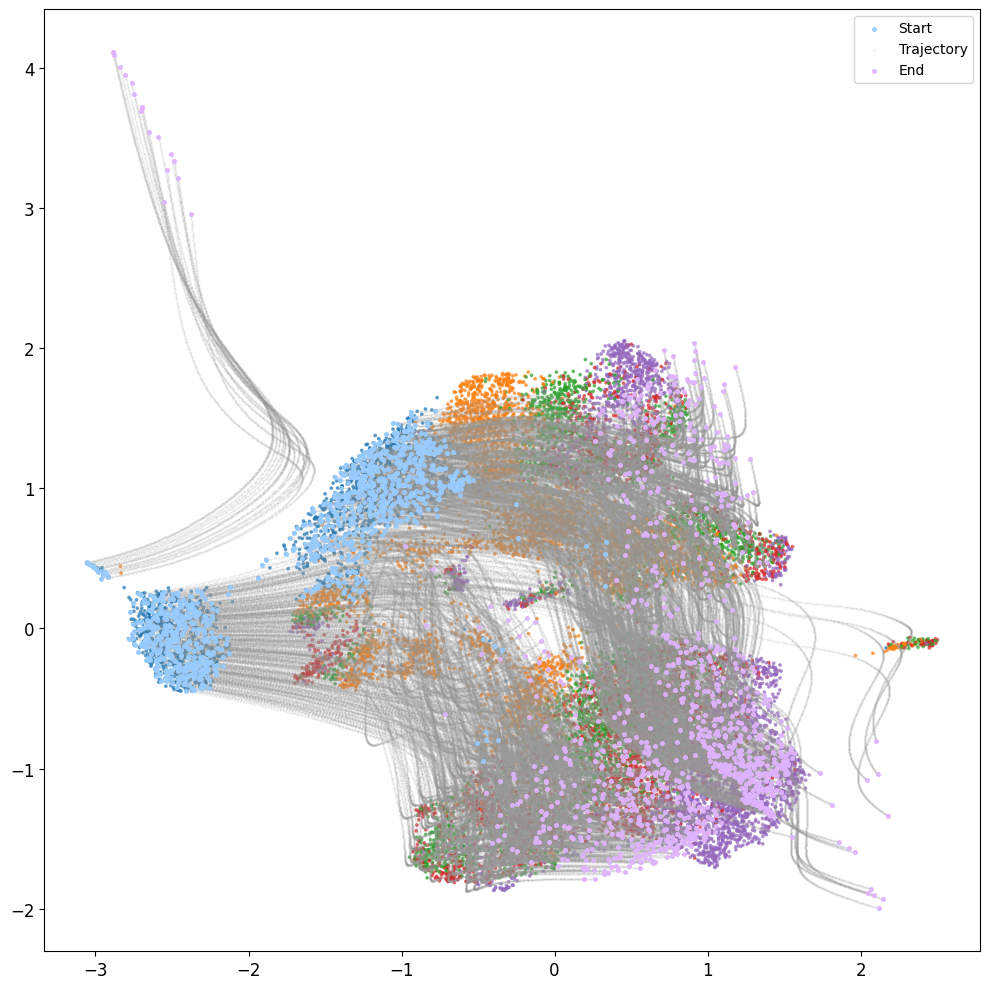

In [13]:
node = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(X[0][:1000]).float().to(device),
        t_span=torch.linspace(0, n_times - 1, 400),
    ).cpu()
    plot_trajectories(traj.cpu().numpy())

In [14]:
torch.save(
    {
        "model": ot_cfm_model,
        "optimizer": ot_cfm_optimizer,
        "loss_history": loss_history
    },
    f"{savedir}/ot_cfm_single_cell.pt",
)

# 1.2 partial ot cfm
部分传输cfm

暂时先别改原来sf2m的部分， 参考otcfm和sf2m来进行修改。 需要手动实现一个PartialOptimalTransportConditionalFlowMatcher 的类, 笑点解析: pot的源代码在此项目中改不了, 转本地

In [16]:
class PartialOptimalTransportConditionalFlowMatcher(ConditionalFlowMatcher):
    """Child class for optimal transport conditional flow matching method.

    It overrides the sample_location_and_conditional_flow.
    """

    def __init__(self, sigma: Union[float, int] = 0.0):
        r"""Initialize the ConditionalFlowMatcher class.

        It requires the hyper-parameter $\sigma$.
                Parameters
                ----------
                sigma : Union[float, int]
                ot_sampler: partial OT method to draw couplings (x0, x1) (see Eq.(17) [1]).
        """
        super().__init__(sigma)
        self.ot_sampler = OTPlanSampler(method="partial") 

    def sample_location_and_conditional_flow(self, x0, x1, t=None, return_noise=False):
        r"""
        Compute the sample xt (drawn from N(t * x1 + (1 - t) * x0, sigma))
        and the conditional vector field ut(x1|x0) = x1 - x0, see Eq.(15) [1]
        with respect to the minibatch OT plan $\Pi$.

        Parameters
        ----------
        x0 : Tensor, shape (bs, *dim)
            represents the source minibatch
        x1 : Tensor, shape (bs, *dim)
            represents the target minibatch
        (optionally) t : Tensor, shape (bs)
            represents the time levels
            if None, drawn from uniform [0,1]
        return_noise : bool
            return the noise sample epsilon

        Returns
        -------
        t : FloatTensor, shape (bs)
        xt : Tensor, shape (bs, *dim)
            represents the samples drawn from probability path pt
        ut : conditional vector field ut(x1|x0) = x1 - x0
        (optionally) epsilon : Tensor, shape (bs, *dim) such that xt = mu_t + sigma_t * epsilon

        References
        ----------
        [1] Improving and Generalizing Flow-Based Generative Models with minibatch optimal transport, Preprint, Tong et al.
        """
        x0, x1 = self.ot_sampler.sample_plan(x0, x1)
        return super().sample_location_and_conditional_flow(x0, x1, t, return_noise)

    def guided_sample_location_and_conditional_flow(
        self, x0, x1, y0=None, y1=None, t=None, return_noise=False
    ):
        r"""
        Compute the sample xt (drawn from N(t * x1 + (1 - t) * x0, sigma))
        and the conditional vector field ut(x1|x0) = x1 - x0, see Eq.(15) [1]
        with respect to the minibatch OT plan $\Pi$.

        Parameters
        ----------
        x0 : Tensor, shape (bs, *dim)
            represents the source minibatch
        x1 : Tensor, shape (bs, *dim)
            represents the target minibatch
        y0 : Tensor, shape (bs) (default: None)
            represents the source label minibatch
        y1 : Tensor, shape (bs) (default: None)
            represents the target label minibatch
        (optionally) t : Tensor, shape (bs)
            represents the time levels
            if None, drawn from uniform [0,1]
        return_noise : bool
            return the noise sample epsilon

        Returns
        -------
        t : FloatTensor, shape (bs)
        xt : Tensor, shape (bs, *dim)
            represents the samples drawn from probability path pt
        ut : conditional vector field ut(x1|x0) = x1 - x0
        (optionally) epsilon : Tensor, shape (bs, *dim) such that xt = mu_t + sigma_t * epsilon

        References
        ----------
        [1] Improving and Generalizing Flow-Based Generative Models with minibatch optimal transport, Preprint, Tong et al.
        """
        x0, x1, y0, y1 = self.ot_sampler.sample_plan_with_labels(x0, x1, y0, y1)
        if return_noise:
            t, xt, ut, eps = super().sample_location_and_conditional_flow(x0, x1, t, return_noise)
            return t, xt, ut, y0, y1, eps
        else:
            t, xt, ut = super().sample_location_and_conditional_flow(x0, x1, t, return_noise)
            return t, xt, ut, y0, y1

In [17]:
# sigma = 0.25
# sf2m_model = MLP(dim=dim, time_varying=True, w=64).to(device)
# sf2m_score_model = MLP(dim=dim, time_varying=True, w=64).to(device)
# sf2m_optimizer = torch.optim.AdamW(
#     list(sf2m_model.parameters()) + list(sf2m_score_model.parameters()), 1e-4
# )
# SF2M = SchrodingerBridgeConditionalFlowMatcher(sigma=sigma)

batch_size = 256
sigma = 0.1
dim = 2
pot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
pot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
PFM = PartialOptimalTransportConditionalFlowMatcher(sigma=sigma)

In [19]:
loss_history = []  # 保存每100步的loss
for i in tqdm(range(1000)):
    pot_cfm_optimizer.zero_grad()
    t, xt, ut = get_batch(PFM, X, batch_size, n_times)
    vt = pot_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)
    loss.backward()
    pot_cfm_optimizer.step()
    # 每100步记录loss
    if (i + 1) % 100 == 0:
        loss_val = loss.item()
        loss_history.append(loss_val)
        tqdm.write(f"迭代步数: {i+1:5d} | Loss: {loss_val:.6f}")

 10%|█         | 100/1000 [01:02<08:58,  1.67it/s]

迭代步数:   100 | Loss: 0.140445


 20%|██        | 200/1000 [03:26<21:05,  1.58s/it]

迭代步数:   200 | Loss: 0.127355


 30%|███       | 300/1000 [06:03<18:08,  1.56s/it]

...

迭代步数:   800 | Loss: 0.128806


 90%|█████████ | 900/1000 [22:34<02:57,  1.78s/it]

迭代步数:   900 | Loss: 0.137425


100%|██████████| 1000/1000 [25:32<00:00,  1.53s/it]

迭代步数:  1000 | Loss: 0.135301


In [20]:
node = NeuralODE(torch_wrapper(pot_cfm_model), solver="euler", sensitivity="adjoint")
x0 = torch.from_numpy(X[0][:1000]).float()
with torch.no_grad():
    traj = node.trajectory(
        x0.to(device),
        t_span=torch.linspace(0, n_times - 1, 400, device=device),
    ).cpu()

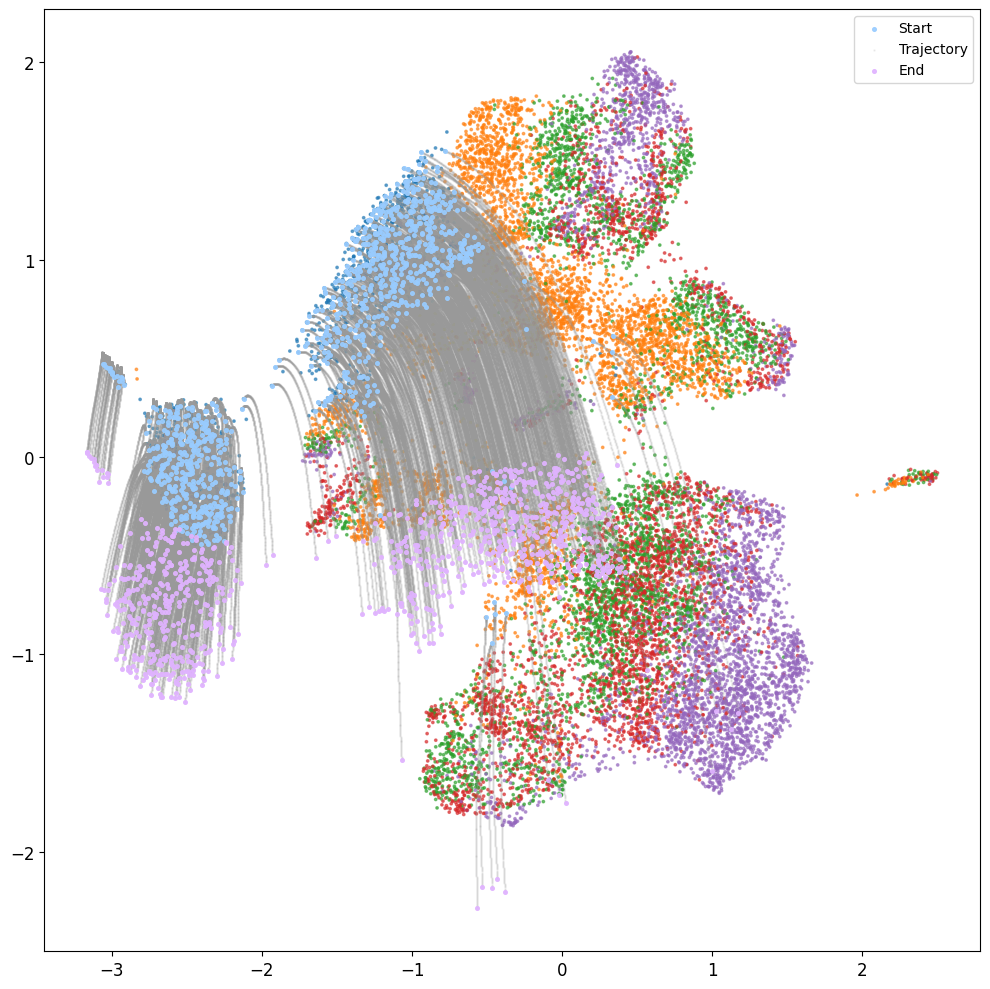

In [21]:
plot_trajectories(traj.cpu().numpy())

In [22]:
torch.save(
    {
        "model": pot_cfm_model,
        "optimizer": pot_cfm_optimizer,
        "loss_history": loss_history
    },
    f"{savedir}/pot_cfm_single_cell_sigma_{sigma}.pt",
)

TODO: 把两个模型生成的轨迹放在一起对比, 似乎没必要了额